# HateBERT: in-domain and cross-domain

Fine-tunes the base `GroNLP/hateBERT` checkpoint twice, each run starting from the base model:
- **In-domain:** train on `olid-train-small.csv`, test on `olid-test.csv`
- **Cross-domain:** train on `hasoc-train.csv`, test on `olid-test.csv`

Hyperparameters are the simpletransformers defaults (no tuning). Trained models are cached in `models/`, predictions in `results/`.

**Setup:**
```bash
python3.13 -m venv venv-a4
source venv-a4/bin/activate
pip install torch transformers accelerate scikit-learn pandas matplotlib ipykernel
```

In [1]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", DEVICE)

/Users/justus/Desktop/projects/subjective-assignment-3/venv-a4/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


In [ ]:
MODEL_NAME = "GroNLP/hateBERT"
SEED = 42
MAX_SEQ_LENGTH = 512
EVAL_BATCH_SIZE = 100

# simpletransformers ClassificationArgs defaults
TRAINING_ARGS = dict(
    num_train_epochs=1,
    learning_rate=4e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=1,
    warmup_steps=0.06,
    lr_scheduler_type="linear",
    weight_decay=0.0,
    adam_epsilon=1e-8,
    adam_beta1=0.9,
    adam_beta2=0.999,
    max_grad_norm=1.0,
    optim="adamw_torch",
    seed=SEED,
)

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [3]:
olid_train = pd.read_csv("data/olid-train-small.csv")
olid_test = pd.read_csv("data/olid-test.csv")
hasoc_train = pd.read_csv("data/hasoc-train.csv")

print("OLID train:", olid_train.shape)
print("OLID test:", olid_test.shape)
print("HASOC train:", hasoc_train.shape)

OLID train: (5852, 3)
OLID test: (860, 3)
HASOC train: (5852, 3)


In [ ]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.encodings = tokenizer(list(df["text"]), truncation=True, max_length=MAX_SEQ_LENGTH)
        self.labels = list(df["labels"])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.encodings.items()}
        item["labels"] = self.labels[i]
        return item


def train_hatebert(train_df, model_dir):
    if os.path.exists(os.path.join(model_dir, "config.json")):
        print(f"{model_dir} exists, skipping training")
        return

    set_seed(SEED)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    args = TrainingArguments(
        output_dir=model_dir,
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        dataloader_pin_memory=False,
        **TRAINING_ARGS,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=TextDataset(train_df, tokenizer),
        data_collator=DataCollatorWithPadding(tokenizer),
    )

    start = time.perf_counter()
    trainer.train()
    train_seconds = time.perf_counter() - start

    trainer.save_model(model_dir)
    tokenizer.save_pretrained(model_dir)

    with open(os.path.join(model_dir, "train_info.json"), "w") as f:
        json.dump({"device": str(trainer.args.device), "train_seconds": round(train_seconds, 1)}, f)
    print(f"Trained on {trainer.args.device} in {train_seconds / 60:.1f} min")


@torch.no_grad()
def predict_hatebert(model_dir, test_df):
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE).eval()

    predictions = []
    for i in range(0, len(test_df), EVAL_BATCH_SIZE):
        batch = tokenizer(
            list(test_df["text"].iloc[i:i + EVAL_BATCH_SIZE]),
            truncation=True,
            max_length=MAX_SEQ_LENGTH,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)
        predictions.append(model(**batch).logits.argmax(dim=-1).cpu().numpy())

    return np.concatenate(predictions)

In [5]:
def run_hatebert(train_df, test_df, experiment_name, model_dir, predictions_path):

    train_hatebert(train_df, model_dir)

    if os.path.exists(predictions_path):
        print(f"{predictions_path} exists, loading saved predictions")
        results = pd.read_csv(predictions_path)
    else:
        results = test_df.copy()
        results["prediction"] = predict_hatebert(model_dir, test_df)
        results["prediction_label"] = results["prediction"].map({0: "NOT", 1: "OFF"})
        results.to_csv(predictions_path, index=False)

    y_test = results["labels"]
    predictions = results["prediction"]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        labels=[0, 1],
        zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    accuracy = accuracy_score(y_test, predictions)

    cm = confusion_matrix(y_test, predictions, labels=[0, 1])

    with open(os.path.join(model_dir, "train_info.json")) as f:
        train_info = json.load(f)

    metrics = {
        "Experiment": experiment_name,
        "NOT Precision": precision[0],
        "NOT Recall": recall[0],
        "NOT F1": f1[0],
        "OFF Precision": precision[1],
        "OFF Recall": recall[1],
        "OFF F1": f1[1],
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Accuracy": accuracy,
        "Device": train_info["device"],
        "Train time (min)": train_info["train_seconds"] / 60
    }

    return results, metrics, cm

In [6]:
hb_olid_results, hb_olid_metrics, hb_cm_olid = run_hatebert(
    olid_train,
    olid_test,
    "In-domain: OLID → OLID",
    "models/hatebert-in-domain",
    "results/hatebert_in-domain_predictions.csv"
)

hb_hasoc_results, hb_hasoc_metrics, hb_cm_hasoc = run_hatebert(
    hasoc_train,
    olid_test,
    "Cross-domain: HASOC → OLID",
    "models/hatebert-cross-domain",
    "results/hatebert_cross-domain_predictions.csv"
)

models/hatebert-in-domain exists, skipping training
results/hatebert_in-domain_predictions.csv exists, loading saved predictions
models/hatebert-cross-domain exists, skipping training
results/hatebert_cross-domain_predictions.csv exists, loading saved predictions


In [7]:
hb_comparison = pd.DataFrame([
    hb_olid_metrics,
    hb_hasoc_metrics
])

hb_comparison.round(4)

,Experiment,NOT Precision,NOT Recall,NOT F1,OFF Precision,OFF Recall,OFF F1,Macro Precision,Macro Recall,Macro F1,Accuracy,Device,Train time (min)
0,In-domain: OLID → OLID,0.8849,0.9177,0.9010,0.7650,0.6917,0.7265,0.8249,0.8047,0.8138,0.8547,mps,8.4733
1,Cross-domain: HASOC → OLID,0.8357,0.9516,0.8899,0.8052,0.5167,0.6294,0.8204,0.7341,0.7597,0.8302,mps,9.1367


In [8]:
hb_drop = (
    hb_olid_metrics["Macro F1"]
    - hb_hasoc_metrics["Macro F1"]
)

hb_relative_drop = (
    hb_drop / hb_olid_metrics["Macro F1"]
) * 100

print(f"In-domain Macro F1:   {hb_olid_metrics['Macro F1']:.4f}")
print(f"Cross-domain Macro F1: {hb_hasoc_metrics['Macro F1']:.4f}")
print(f"Absolute drop:         {hb_drop:.4f}")
print(f"Relative drop:         {hb_relative_drop:.2f}%")

In-domain Macro F1:   0.8138
Cross-domain Macro F1: 0.7597
Absolute drop:         0.0541
Relative drop:         6.65%


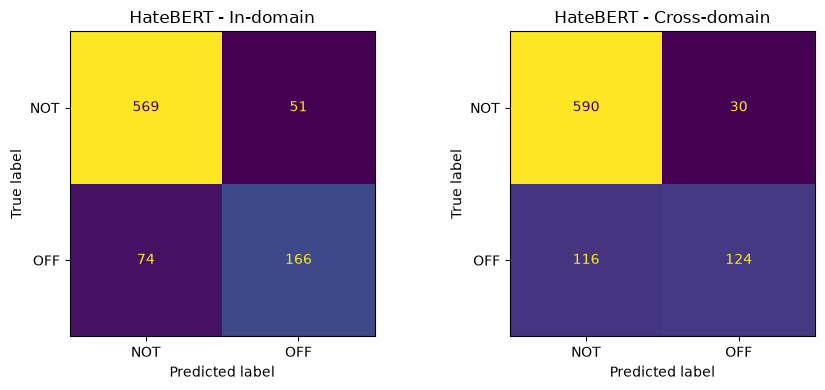

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, cm, title in [
    (axes[0], hb_cm_olid, "HateBERT - In-domain"),
    (axes[1], hb_cm_hasoc, "HateBERT - Cross-domain")
]:
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NOT", "OFF"]).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("figures/hatebert_confusion_matrices.pdf", bbox_inches="tight")
plt.show()

In [10]:
def error_counts(results):

    false_positives = results[
        (results["labels"] == 0) &
        (results["prediction"] == 1)
    ]

    false_negatives = results[
        (results["labels"] == 1) &
        (results["prediction"] == 0)
    ]

    return len(false_positives), len(false_negatives)


olid_fp, olid_fn = error_counts(hb_olid_results)
hasoc_fp, hasoc_fn = error_counts(hb_hasoc_results)

print("IN-DOMAIN")
print("False positives:", olid_fp)
print("False negatives:", olid_fn)

print("\nCROSS-DOMAIN")
print("False positives:", hasoc_fp)
print("False negatives:", hasoc_fn)

IN-DOMAIN
False positives: 51
False negatives: 74

CROSS-DOMAIN
False positives: 30
False negatives: 116
